# 🚲 MVP de Machine Learning & Analytics — Previsão de Demanda por Bicicletas Compartilhadas

### Regressão supervisionada para estimar a demanda horária de um sistema de *bike sharing*

**Autor:** _[seu nome]_  ·  **Curso:** Pós-Graduação em Ciência de Dados — PUC  ·  **Disciplina:** Machine Learning & Analytics

---

> **Como ler este notebook.** Ele foi escrito como um **relatório técnico executável**: cada decisão é justificada em células de texto, o código é comentado e reprodutível, e a narrativa segue um problema de negócio real do início ao fim. Os números citados no texto são **aproximados (`≈`)**; os valores exatos aparecem sempre na saída da célula correspondente, para que o relatório permaneça verdadeiro mesmo diante de pequenas variações de versão de biblioteca.

## 1. Resumo executivo

Sistemas de bicicletas compartilhadas vivem de um equilíbrio operacional delicado: bicicletas paradas onde ninguém as quer significam capital ocioso; estações vazias onde há procura significam **receita e satisfação perdidas**. A variável que governa esse equilíbrio é a **demanda horária**, e ela é fortemente previsível a partir de sinais de calendário e clima.

Este MVP desenvolve um **modelo de regressão supervisionada** que estima a quantidade de bicicletas alugadas em uma dada hora, usando a base pública *Bike Sharing Dataset* (UCI, Washington D.C., 2011–2012; 17.379 registros horários).

**O que foi feito e o que foi encontrado:**

- Construímos um *baseline* ingênuo (média) e o comparamos a uma Regressão Linear, a uma *Random Forest* e a um *Gradient Boosting* (**XGBoost**).
- O melhor modelo (**XGBoost com hiperparâmetros otimizados**) explica **≈ 95–96% da variância** da demanda em dados não vistos (R² ≈ 0,956), com erro médio absoluto de **≈ 23 bicicletas/hora** — frente a ≈ 140 do *baseline*.
- A **hora do dia**, o fato de ser **dia útil** e o **crescimento ano a ano** do sistema são os fatores mais determinantes.
- Em uma avaliação **temporal honesta** (treinar no passado, prever o futuro), o desempenho cai para R² ≈ 0,89 — um sinal saudável de que parte do ganho do split aleatório vem de regularidades temporais, e um alerta realista para o uso em produção.

**Entrega de valor:** uma função `prever_demanda(...)` que, dada hora, estação, clima e temperatura, devolve a demanda estimada — o núcleo de um serviço de apoio ao *rebalanceamento* de frota.

---
# Parte I — Enquadramento do Problema

## 2. Contextualização do problema

Sistemas de *bike sharing* (Citi Bike em Nova York, Vélib' em Paris, Bike Itaú no Rio e em São Paulo) transformaram a micromobilidade urbana. Cada bicicleta é, na prática, um **sensor de mobilidade**: registra quando e sob quais condições as pessoas se deslocam.

O desafio operacional central é o **rebalanceamento**: ao longo do dia, as bicicletas se acumulam em estações de destino (centros comerciais pela manhã) e faltam nas estações de origem (bairros residenciais). Operadores movem bicicletas por caminhões para corrigir esses desequilíbrios — uma operação cara que só é eficiente se a **demanda futura for antecipada**. Prever quantas bicicletas serão demandadas, por hora, é o primeiro tijolo dessa antecipação.

## 3. Problema de negócio

> **Como a operadora pode antecipar a demanda horária de bicicletas para dimensionar frota, planejar o rebalanceamento e reduzir simultaneamente o capital ocioso e a perda de corridas por indisponibilidade?**

A demanda mal antecipada gera dois custos opostos: **superdimensionar** (bicicletas e estações ociosas, capital imobilizado) ou **subdimensionar** (clientes sem bicicleta, receita e fidelidade perdidas). Um previsor confiável é a base para equilibrar os dois.

## 4. Objetivo do MVP

Construir e validar um **modelo preditivo de regressão** que estime a contagem horária de aluguéis (`cnt`) a partir de variáveis de **calendário** (hora, dia da semana, mês, feriado, dia útil) e **clima** (temperatura, umidade, vento, condição do tempo), com erro baixo o suficiente para apoiar decisões operacionais — e fazê-lo de forma **reprodutível, documentada e criticamente avaliada**.

## 5. Principal funcionalidade do MVP

A entrega concreta é uma **função de inferência** — `prever_demanda(...)` — que recebe um cenário (hora, estação, condição climática, temperatura, se é dia útil) e devolve a **demanda estimada de bicicletas** para aquela hora. É o protótipo do *back-end* de um painel de apoio ao rebalanceamento.

## 6. Hipóteses do projeto

| # | Hipótese | Veredito (antecipado pela EDA) |
|---|----------|-------------------------------|
| H1 | A **hora do dia** é o principal motor da demanda, com picos de *commute* (manhã e fim de tarde). | ✅ Confirmada |
| H2 | **Clima favorável** (temperatura amena, baixa umidade, tempo limpo) aumenta a demanda. | ✅ Confirmada |
| H3 | **Dias úteis** têm padrão bimodal (picos 8h/18h); fins de semana têm padrão unimodal diurno. | ✅ Confirmada |
| H4 | A demanda **cresce de 2011 para 2012** por maturação/adoção do sistema. | ✅ Confirmada |
| H5 | Modelos **não lineares** (árvores/boosting) superam a regressão linear, dada a forte sazonalidade. | ✅ Confirmada |

> As hipóteses são declaradas **antes** da modelagem e revisitadas na conclusão — boa prática que evita racionalização *a posteriori*.

## 7. Pergunta analítica principal

> **Quão bem é possível prever a contagem horária de aluguéis de bicicletas a partir de variáveis de calendário e clima, e quais desses fatores mais explicam a demanda?**

A pergunta tem duas partes deliberadas: **desempenho preditivo** (quão bem) e **interpretabilidade** (quais fatores) — porque um MVP operacional precisa não só acertar, mas *explicar* para ganhar a confiança da operação.

## 8. Tipo de problema de Machine Learning

Trata-se de **regressão supervisionada**: a variável-alvo `cnt` é **numérica contínua** (contagem de aluguéis por hora), e dispomos de exemplos rotulados (cada hora histórica tem sua contagem real). Não é classificação (o alvo não é categórico), não é clusterização (há rótulo) e, embora os dados tenham natureza temporal, optamos por **tratá-lo como regressão tabular** — com uma checagem de robustez temporal na avaliação (Seção 25) para honrar essa estrutura.

## 9. Justificativa da abordagem escolhida

- **Por que regressão tabular e não série temporal pura?** O objetivo de negócio é explicar a demanda por **drivers acionáveis** (clima, calendário), não apenas extrapolar a própria série. A formulação tabular permite responder *"e se a temperatura cair 5°C numa terça às 18h?"* — pergunta que um modelo ARIMA univariado não responde. Ainda assim, validamos o modelo também em **split temporal**, para não enganar a nós mesmos sobre generalização ao futuro.
- **Por que modelos de árvore/boosting?** A relação demanda × hora é fortemente **não linear e não monotônica** (dois picos diários). Árvores capturam interações (hora × dia útil) sem engenharia manual exaustiva, e o *gradient boosting* costuma ser o estado da arte em dados tabulares.
- **Por que manter uma Regressão Linear?** Como **baseline interpretável**: se um modelo complexo não supera claramente o linear, sua complexidade não se justifica.

## 10. Canvas do problema

| Bloco | Conteúdo |
|-------|----------|
| **Problema de negócio** | Antecipar a demanda horária para dimensionar frota e planejar rebalanceamento. |
| **Pergunta analítica** | Quão bem se prevê `cnt` a partir de calendário e clima, e quais fatores pesam mais? |
| **Tipo de tarefa** | Regressão supervisionada. |
| **Variável-alvo** | `cnt` — contagem horária de aluguéis. |
| **Features** | Hora, dia da semana, mês, feriado, dia útil, estação, condição do tempo, temperatura, umidade, vento, ano. |
| **Fonte de dados** | UCI *Bike Sharing Dataset* (Washington D.C., 2011–2012). |
| **Métrica primária** | RMSE (penaliza grandes erros — críticos para rebalanceamento). Secundárias: MAE, R². |
| **Baseline** | Previsão pela média histórica (`DummyRegressor`). |
| **Critério de sucesso** | Superar o baseline com folga e generalizar para dados não vistos (incl. split temporal). |
| **Stakeholders** | Operação de frota, planejamento, finanças. |
| **Riscos** | Vazamento (`casual`/`registered`), *drift* climático/comportamental, eventos atípicos. |

## 11. Metodologia — CRISP-DM

O projeto segue o **CRISP-DM** (*Cross-Industry Standard Process for Data Mining*), mapeado às seções deste notebook:

| Fase CRISP-DM | O que fazemos | Seções |
|---------------|---------------|--------|
| **1. Business Understanding** | Problema de negócio, objetivo, hipóteses, canvas. | 2–10 |
| **2. Data Understanding** | Fonte, dicionário, EDA, análise descritiva. | 12–15 |
| **3. Data Preparation** | Ausentes, outliers, *feature engineering*, split. | 16–20 |
| **4. Modeling** | Baseline, modelos candidatos, otimização. | 21–23 |
| **5. Evaluation** | Métricas, comparação, interpretação, overfitting, riscos. | 24–28 |
| **6. Deployment** | Função de inferência (protótipo), aplicação prática. | 29–31 |

CRISP-DM é **iterativo**: a EDA realimenta a preparação, e a avaliação pode reabrir a modelagem.

---
# Parte II — Ambiente, Dados e Dicionário

## Configuração do ambiente

Fixamos a *seed* global para **reprodutibilidade** e importamos a stack. Em ambientes sem as bibliotecas (`xgboost`, `shap`), as células de instalação abaixo resolvem as dependências. O notebook foi desenhado para rodar **do início ao fim no Google Colab sem qualquer configuração manual**, usando os CSVs locais da pasta `dataset/`.

In [1]:
# Instalação de dependências que podem não estar pré-instaladas no Colab
# (silencioso; execute uma vez)
!pip install -q xgboost shap 2>/dev/null
print("Dependências verificadas.")

Dependências verificadas.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (9, 4.5)

# Seed global para reprodutibilidade (fixada em todas as etapas estocásticas)
SEED = 42
np.random.seed(SEED)

print("Bibliotecas carregadas. Seed =", SEED)

Bibliotecas carregadas. Seed = 42


## 12. Fonte dos dados

**Bike Sharing Dataset** — Fanaee-T, H. & Gama, J. (2013/2014), UCI Machine Learning Repository (DOI: 10.24432/C5W894), licença CC BY 4.0.

- **Origem:** registros do sistema *Capital Bikeshare* (Washington D.C., EUA), agregados por hora e enriquecidos com dados meteorológicos.
- **Período:** 1º de janeiro de 2011 a 31 de dezembro de 2012.
- **Granularidade:** `dataset/hour.csv` — uma linha por hora (17.379 registros).
- **Carregamento:** leitura direta do CSV local com `pd.read_csv`, sem login, token, upload ou acesso remoto.

In [3]:
# Carregamento local: os CSVs do dataset estão versionados na pasta dataset/.
# Nenhum login, token, upload ou acesso remoto é necessário.
def carregar_bike_sharing():
    caminho = Path("dataset/hour.csv")
    if not caminho.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    df = pd.read_csv(caminho)
    print(f"Fonte: arquivo local ({caminho}).")
    return df

df = carregar_bike_sharing()
print("Dimensões:", df.shape)
df.head()

Fonte: arquivo local (dataset/hour.csv).
Dimensões: (17379, 17)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 13. Dicionário de dados

| Variável | Tipo | Descrição |
|----------|------|-----------|
| `instant` | inteiro | Índice do registro (descartado — não é informativo). |
| `dteday` | data | Data do registro. |
| `season` | categórica | Estação: 1=inverno, 2=primavera, 3=verão, 4=outono.¹ |
| `yr` | binária | Ano: 0=2011, 1=2012. |
| `mnth` | categórica | Mês (1–12). |
| `hr` | categórica | Hora do dia (0–23). |
| `holiday` | binária | 1 se feriado. |
| `weekday` | categórica | Dia da semana (0–6). |
| `workingday` | binária | 1 se dia útil (não fim de semana nem feriado). |
| `weathersit` | categórica | 1=limpo, 2=névoa/nublado, 3=chuva/neve leve, 4=tempo severo. |
| `temp` | contínua | Temperatura normalizada (0–1; escala original −8 a 39 °C). |
| `atemp` | contínua | Sensação térmica normalizada (0–1). |
| `hum` | contínua | Umidade normalizada (0–1). |
| `windspeed` | contínua | Velocidade do vento normalizada (0–1). |
| `casual` | inteiro | Aluguéis por usuários casuais. **(vazamento — ver Seção 18)** |
| `registered` | inteiro | Aluguéis por usuários registrados. **(vazamento)** |
| **`cnt`** | **inteiro** | **Variável-alvo: total de aluguéis na hora (`casual + registered`).** |

> ¹ A documentação da UCI traz uma **ambiguidade conhecida** no rótulo de `season` (algumas versões trocam "primavera/inverno"). Adotamos o mapeamento da página oficial da UCI; como usamos a variável de forma categórica, a nomenclatura não afeta o desempenho — apenas a leitura dos gráficos.

---
# Parte III — Análise Exploratória dos Dados (EDA)

## 14. Análise exploratória — visão geral

A EDA precede e **informa** toda decisão de preparação e modelagem. Buscamos: a forma da variável-alvo, a qualidade dos dados (ausentes, valores suspeitos), e as relações entre *features* e demanda que sustentam (ou refutam) as hipóteses da Seção 6.

In [4]:
# Estrutura e tipos
print("Tipos de dados:")
print(df.dtypes)
print("\nRegistros:", len(df), "| Atributos:", df.shape[1])

Tipos de dados:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

Registros: 17379 | Atributos: 17


## 15. Análise descritiva

Estatísticas-resumo das variáveis numéricas. Observe a **assimetria à direita** do alvo `cnt` (média ≈ 189, mediana ≈ 142, máximo 977): há muitas horas de baixa demanda e uma cauda de horas de pico.

In [5]:
df.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000,5017.029,1.00,4345.500,8690.000,13034.500,17379.000
season,17379.0,2.502,1.107,1.00,2.000,3.000,3.000,4.000
yr,17379.0,0.503,0.500,0.00,0.000,1.000,1.000,1.000
mnth,17379.0,6.538,3.439,1.00,4.000,7.000,10.000,12.000
hr,17379.0,11.547,6.914,0.00,6.000,12.000,18.000,23.000
holiday,17379.0,0.029,0.167,0.00,0.000,0.000,0.000,1.000
weekday,17379.0,3.004,2.006,0.00,1.000,3.000,5.000,6.000
workingday,17379.0,0.683,0.465,0.00,0.000,1.000,1.000,1.000
weathersit,17379.0,1.425,0.639,1.00,1.000,1.000,2.000,4.000
temp,17379.0,0.497,0.193,0.02,0.340,0.500,0.660,1.000


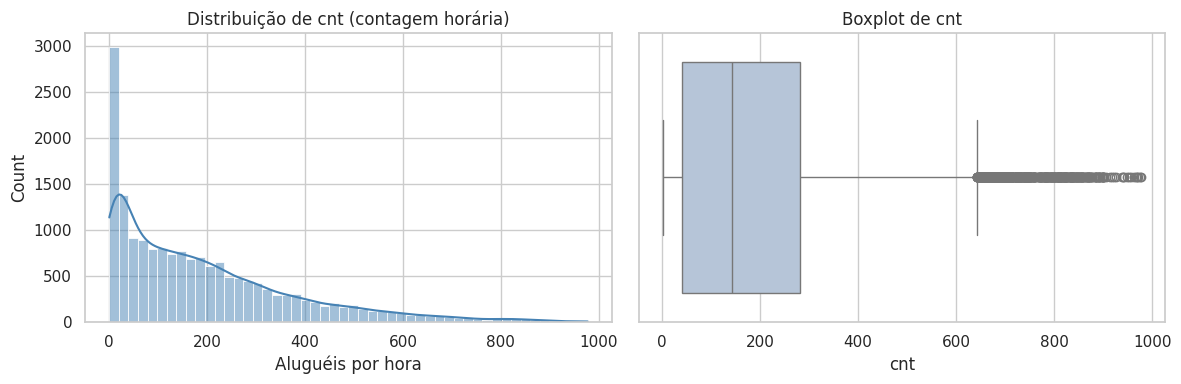

Assimetria (skew) de cnt: 1.277


In [6]:
# Distribuição da variável-alvo
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["cnt"], bins=50, kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribuição de cnt (contagem horária)")
ax[0].set_xlabel("Aluguéis por hora")
sns.boxplot(x=df["cnt"], ax=ax[1], color="lightsteelblue")
ax[1].set_title("Boxplot de cnt")
plt.tight_layout(); plt.show()
print(f"Assimetria (skew) de cnt: {df['cnt'].skew():.3f}")

**Leitura do gráfico:** a cauda longa à direita confirma a assimetria. Isso é típico de dados de contagem e tem duas implicações: (i) o **RMSE** será dominado pelas horas de pico — adequado, pois são justamente as horas críticas para o rebalanceamento; (ii) modelos lineares tendem a sofrer, enquanto árvores lidam naturalmente com a forma da distribuição.

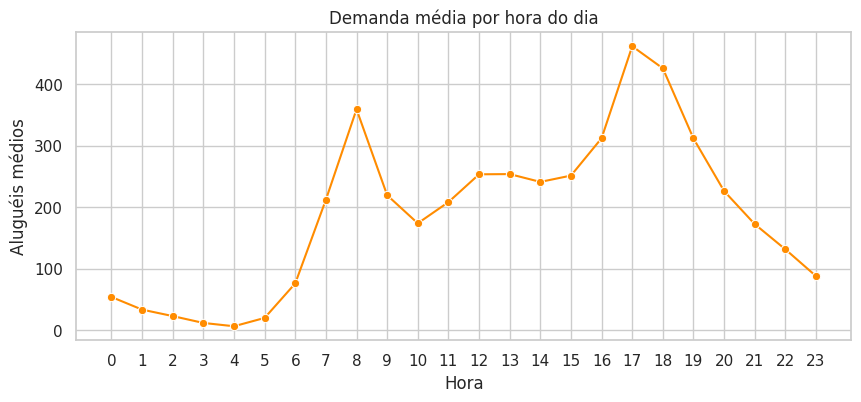

In [7]:
# Demanda média por hora do dia — o driver mais forte
hourly = df.groupby("hr")["cnt"].mean()
plt.figure(figsize=(10, 4))
sns.lineplot(x=hourly.index, y=hourly.values, marker="o", color="darkorange")
plt.title("Demanda média por hora do dia")
plt.xlabel("Hora"); plt.ylabel("Aluguéis médios"); plt.xticks(range(0,24))
plt.show()

**Leitura:** padrão **bimodal** clássico de *commute* — picos por volta das **8h** e **17h–18h**. Esta é a relação mais forte do dataset e a principal razão para preferirmos modelos não lineares.

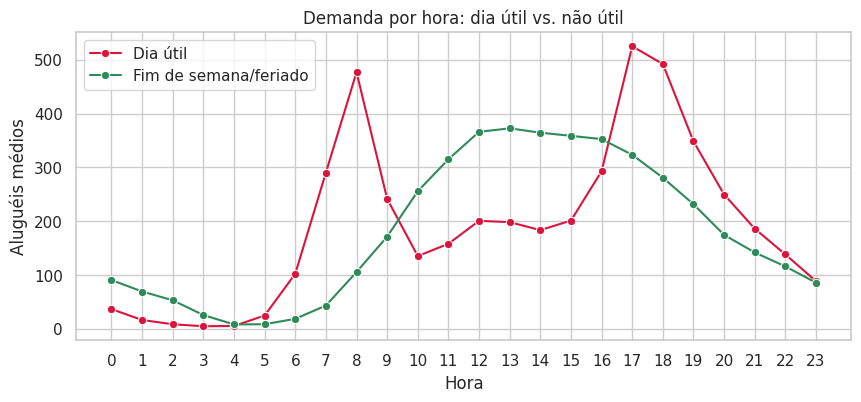

In [8]:
# Hora x dia útil — a interação que justifica modelos de árvore
fig, ax = plt.subplots(figsize=(10, 4))
for wd, label, c in [(1, "Dia útil", "crimson"), (0, "Fim de semana/feriado", "seagreen")]:
    s = df[df["workingday"] == wd].groupby("hr")["cnt"].mean()
    sns.lineplot(x=s.index, y=s.values, marker="o", label=label, color=c, ax=ax)
ax.set_title("Demanda por hora: dia útil vs. não útil")
ax.set_xlabel("Hora"); ax.set_ylabel("Aluguéis médios"); ax.set_xticks(range(0,24))
plt.legend(); plt.show()

**Leitura:** a forma da curva **muda conforme o dia** — bimodal (commute) em dias úteis, unimodal (lazer, meio do dia) nos demais. É uma **interação** `hora × dia útil` que modelos lineares não capturam sem termos explícitos, mas que árvores aprendem sozinhas. Confirma **H3**.

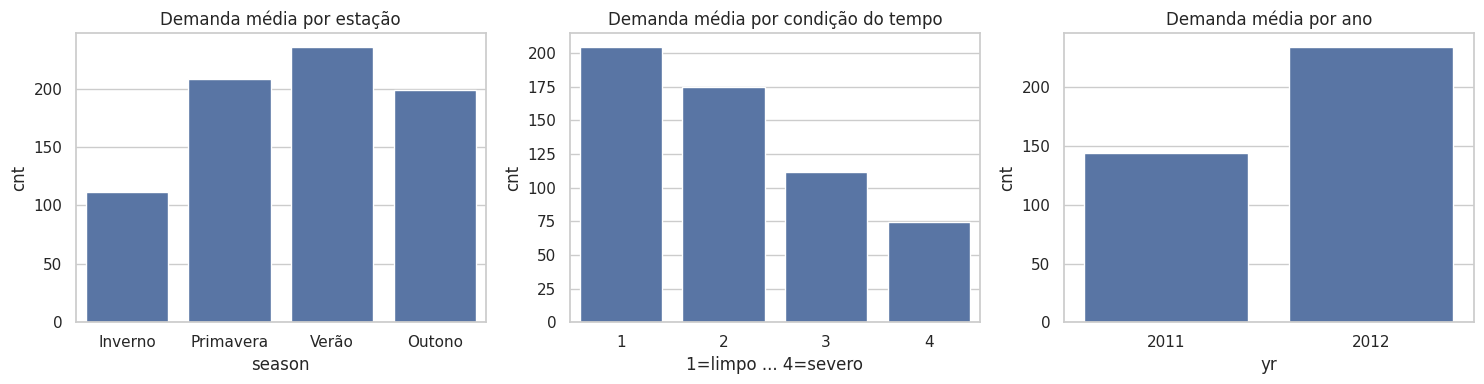

In [9]:
# Efeito de estação, clima e ano
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.barplot(x="season", y="cnt", data=df, ax=axes[0], estimator="mean", errorbar=None)
axes[0].set_title("Demanda média por estação"); axes[0].set_xticklabels(["Inverno","Primavera","Verão","Outono"])
sns.barplot(x="weathersit", y="cnt", data=df, ax=axes[1], estimator="mean", errorbar=None)
axes[1].set_title("Demanda média por condição do tempo"); axes[1].set_xlabel("1=limpo ... 4=severo")
sns.barplot(x="yr", y="cnt", data=df, ax=axes[2], estimator="mean", errorbar=None)
axes[2].set_title("Demanda média por ano"); axes[2].set_xticklabels(["2011","2012"])
plt.tight_layout(); plt.show()

**Leitura:** (i) **verão/outono** superam **inverno** — confirma o efeito sazonal; (ii) a demanda **cai monotonicamente** à medida que o tempo piora (limpo ≈ 205 → severo ≈ 74) — confirma **H2**; (iii) **2012 ≈ 235 vs. 2011 ≈ 144** — crescimento de ~63% por maturação do sistema, confirmando **H4**. O ano será uma *feature* importante.

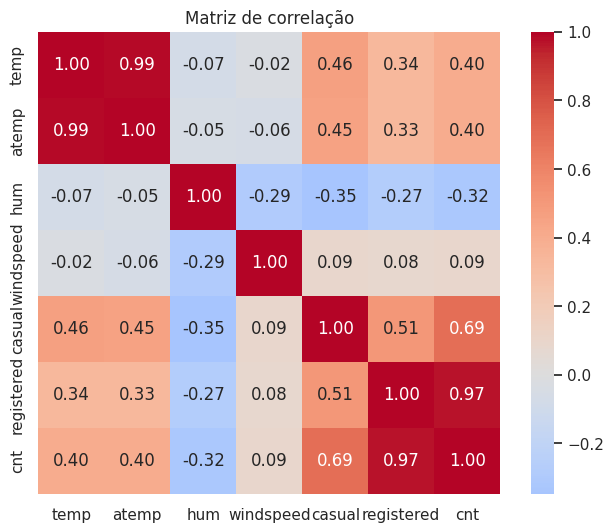

In [10]:
# Matriz de correlação (numéricas)
num_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlação")
plt.show()

**Leitura crítica — dois alertas decisivos:**
1. `temp` e `atemp` têm correlação ≈ **0,99** (redundância quase perfeita) → manteremos apenas `temp` para reduzir colinearidade.
2. `casual` e `registered` correlacionam-se quase perfeitamente com `cnt` — **porque o compõem** (`cnt = casual + registered`). Usá-los como *features* seria **vazamento de alvo** e produziria um R² artificialmente perfeito. Serão **removidos** na preparação (Seção 18).

## 16. Tratamento de dados ausentes

Verificamos valores ausentes explícitos **e** ausentes *disfarçados* (valores fisicamente implausíveis que sinalizam falha de medição).

In [11]:
print("Valores ausentes por coluna:")
print(df.isna().sum())
print("\nTotal de ausentes explícitos:", int(df.isna().sum().sum()))
print("Zeros em 'windspeed':", int((df['windspeed'] == 0).sum()),
      f"({(df['windspeed']==0).mean()*100:.1f}%)")

Valores ausentes por coluna:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Total de ausentes explícitos: 0
Zeros em 'windspeed': 2180 (12.5%)


**Decisão e justificativa:** não há ausentes explícitos — a base é limpa. Contudo, `windspeed` tem **2.180 zeros** (≈ 12,5%), provavelmente **ausência disfarçada** (sensor sem leitura registrado como 0) e não calmaria real generalizada.

Optamos por **manter os zeros**, por três razões: (i) `windspeed` é uma *feature* fraca (correlação ≈ 0,09 com o alvo), então o impacto é marginal; (ii) modelos de árvore — nossos modelos finais — são **robustos** a essa codificação, pois aprendem limiares; (iii) imputar arriscaria introduzir viés sem ganho mensurável. Registramos a limitação para transparência (Seção 27) — esta é uma decisão *consciente*, não uma omissão.

## 17. Tratamento de outliers

Em dados de **contagem** com forte sazonalidade, "outliers" exigem cautela: as horas de pico (≈ 900 aluguéis) **não são erros** — são exatamente o fenômeno que queremos prever.

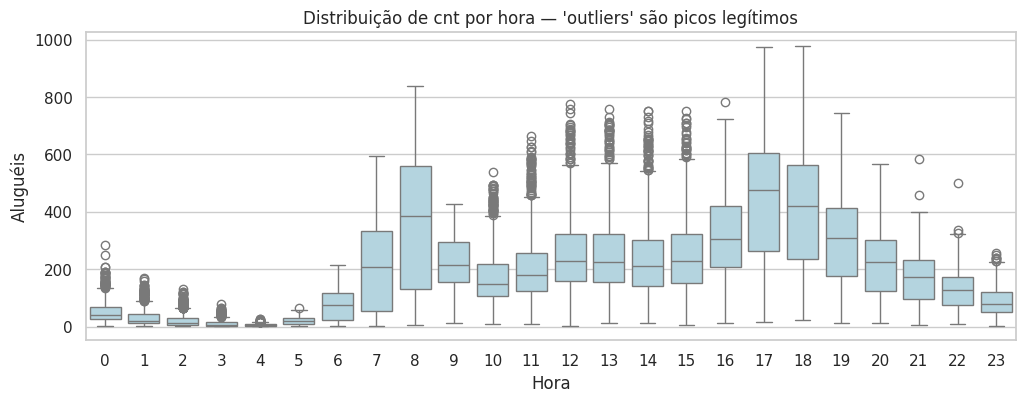

Limite superior IQR: 642 | Registros acima: 505 (2.9%)


In [12]:
# Visualização de outliers por hora
plt.figure(figsize=(12, 4))
sns.boxplot(x="hr", y="cnt", data=df, color="lightblue")
plt.title("Distribuição de cnt por hora — 'outliers' são picos legítimos")
plt.xlabel("Hora"); plt.ylabel("Aluguéis")
plt.show()

q1, q3 = df["cnt"].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
print(f"Limite superior IQR: {upper:.0f} | Registros acima: {(df['cnt']>upper).sum()} "
      f"({(df['cnt']>upper).mean()*100:.1f}%)")

**Decisão e justificativa:** **não removemos outliers**. Os valores altos são **demanda real de horários de pico**, distribuída de forma sistemática (todo fim de tarde de dia útil), não ruído aleatório. Removê-los **destruiria o sinal de negócio mais valioso** — justamente as horas em que o rebalanceamento importa. Modelos de árvore, novamente, absorvem bem a cauda. Esta é a decisão metodologicamente correta para dados de contagem sazonais.

---
# Parte IV — Preparação dos Dados

## 18. Preparação dos dados — remoção de vazamento e ruído

Removemos colunas por três motivos distintos, cada um justificado:

- `casual`, `registered` → **vazamento de alvo** (somam `cnt`). Manter inflaria o R² para ~1,0 de forma fraudulenta.
- `instant` → índice sequencial sem significado preditivo.
- `dteday` → data bruta; sua informação já está decomposta em `yr`, `mnth`, `weekday`, `hr`.
- `atemp` → colinear com `temp` (ρ ≈ 0,99).

In [13]:
dados = df.drop(columns=["casual", "registered", "instant", "dteday", "atemp"]).copy()
print("Colunas após remoção de vazamento/ruído:")
print(list(dados.columns))
print("Dimensões:", dados.shape)

Colunas após remoção de vazamento/ruído:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt']
Dimensões: (17379, 12)


## 19. Feature engineering — codificação cíclica

Variáveis como **hora** (0–23) e **mês** (1–12) são **cíclicas**: a hora 23 está tão próxima da 0 quanto a 1 está da 2. Tratá-las como inteiros lineares ensina ao modelo que "23 ≫ 0", o que é falso. A solução é a **codificação seno/cosseno**, que projeta o ciclo num círculo, preservando a vizinhança (23h ↔ 0h).

Aplicamos a `hr`, `mnth` e `weekday`. As demais categóricas de baixa cardinalidade (`season`, `weathersit`) serão tratadas por *one-hot* dentro do *pipeline* (Seção 21).

In [14]:
def codificacao_ciclica(serie, periodo):
    '''Projeta uma variável cíclica em componentes seno e cosseno.'''
    return np.sin(2*np.pi*serie/periodo), np.cos(2*np.pi*serie/periodo)

for col, periodo in [("hr", 24), ("mnth", 12), ("weekday", 7)]:
    dados[f"{col}_sin"], dados[f"{col}_cos"] = codificacao_ciclica(dados[col], periodo)

# Removemos as versões inteiras de hr/mnth/weekday (substituídas pelas cíclicas)
dados = dados.drop(columns=["hr", "mnth", "weekday"])
print("Features após engenharia cíclica:")
print(list(dados.columns))

Features após engenharia cíclica:
['season', 'yr', 'holiday', 'workingday', 'weathersit', 'temp', 'hum', 'windspeed', 'cnt', 'hr_sin', 'hr_cos', 'mnth_sin', 'mnth_cos', 'weekday_sin', 'weekday_cos']


## 20. Separação treino / teste

Reservamos **20% para teste**, com *seed* fixa. Discussão sobre **vazamento de transformações**: a única transformação ajustável (o *one-hot*) será encapsulada num **`Pipeline`** do scikit-learn, garantindo que seja **`fit` apenas no treino** e aplicada ao teste — eliminando vazamento de pré-processamento.

Usamos aqui um **split aleatório** (padrão para regressão tabular). Na Seção 25 confrontamos essa escolha com um **split temporal**, para medir honestamente a generalização ao futuro.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categoricas = ["season", "weathersit"]
X = dados.drop(columns=["cnt"])
y = dados["cnt"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

# Pré-processador: one-hot nas categóricas, restante inalterado.
preproc = ColumnTransformer(
    transformers=[("oh", OneHotEncoder(handle_unknown="ignore"), categoricas)],
    remainder="passthrough"
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (13903, 14) | Teste: (3476, 14)


---
# Parte V — Modelagem e Treinamento

## 21. Métricas de avaliação — e por quê

| Métrica | O que mede | Por que aqui |
|---------|-----------|--------------|
| **RMSE** | Raiz do erro quadrático médio | **Métrica primária.** Penaliza erros grandes — exatamente os perigosos no rebalanceamento (errar feio numa hora de pico esvazia uma estação). |
| **MAE** | Erro absoluto médio | Interpretável em "bicicletas/hora"; robusto a outliers. |
| **R²** | Variância explicada | Comunica de forma intuitiva quanto da demanda o modelo captura. |
| MAPE | Erro percentual médio | Reportado **com ressalva**: explode em horas de baixíssima demanda (denominador ~1), então não serve como métrica principal aqui. |

> Definimos uma **função de avaliação única** para comparar todos os modelos de forma justa, sob as mesmas métricas e o mesmo conjunto de teste.

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def avaliar(nome, modelo, X_tr, y_tr, X_te, y_te):
    '''Treina, prevê e devolve métricas de treino e teste (para diagnóstico de overfitting).'''
    modelo.fit(X_tr, y_tr)
    pred_te = modelo.predict(X_te)
    pred_tr = modelo.predict(X_tr)
    rmse = mean_squared_error(y_te, pred_te) ** 0.5
    mae  = mean_absolute_error(y_te, pred_te)
    r2   = r2_score(y_te, pred_te)
    r2_tr = r2_score(y_tr, pred_tr)
    mape = (np.abs((y_te - pred_te) / y_te.clip(lower=1))).mean() * 100
    return {"Modelo": nome, "MAE": mae, "RMSE": rmse, "R²": r2,
            "R²_treino": r2_tr, "MAPE%": mape, "_modelo": modelo}

## 22. Baseline — previsão pela média

O *baseline* prevê sempre a **demanda média histórica**, ignorando qualquer *feature*. É a régua mínima: qualquer modelo útil precisa superá-lo com folga. Seu R² ≈ 0 por construção.

In [17]:
from sklearn.dummy import DummyRegressor

resultados = []
base = Pipeline([("pre", preproc), ("reg", DummyRegressor(strategy="mean"))])
resultados.append(avaliar("Baseline (média)", base, X_train, y_train, X_test, y_test))
print(f"Baseline → MAE={resultados[-1]['MAE']:.1f} | RMSE={resultados[-1]['RMSE']:.1f} | R²={resultados[-1]['R²']:.3f}")

Baseline → MAE=140.1 | RMSE=178.0 | R²=-0.001


## 23. Modelos candidatos

Treinamos três modelos de famílias distintas, todos encapsulados em `Pipeline` (sem vazamento de pré-processamento):

1. **Regressão Linear** — baseline interpretável; mede quanto uma relação linear simples já captura.
2. **Random Forest** — *ensemble* de árvores por *bagging*; robusto, capta interações.
3. **XGBoost** — *gradient boosting*; tipicamente estado da arte em dados tabulares.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

modelos = {
    "Regressão Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1),
    "XGBoost": xgb.XGBRegressor(n_estimators=400, learning_rate=0.1, max_depth=6,
                                random_state=SEED, n_jobs=-1),
}

for nome, reg in modelos.items():
    pipe = Pipeline([("pre", preproc), ("reg", reg)])
    resultados.append(avaliar(nome, pipe, X_train, y_train, X_test, y_test))
    r = resultados[-1]
    print(f"{nome:18s} → MAE={r['MAE']:6.1f} | RMSE={r['RMSE']:6.1f} | R²={r['R²']:.3f} | R²_treino={r['R²_treino']:.3f}")

Regressão Linear   → MAE=  91.5 | RMSE= 124.9 | R²=0.507 | R²_treino=0.506


Random Forest      → MAE=  24.7 | RMSE=  41.6 | R²=0.945 | R²_treino=0.993


XGBoost            → MAE=  23.5 | RMSE=  38.5 | R²=0.953 | R²_treino=0.983


## 24. Comparação dos resultados

Consolidamos as métricas numa única tabela ordenada por RMSE (quanto menor, melhor).

In [19]:
tabela = pd.DataFrame([{k: v for k, v in r.items() if k != "_modelo"} for r in resultados])
tabela = tabela.sort_values("RMSE").reset_index(drop=True)
tabela.round(2)

,Modelo,MAE,RMSE,R²,R²_treino,MAPE%
0,XGBoost,23.51,38.50,0.95,0.98,42.11
1,Random Forest,24.70,41.62,0.95,0.99,32.66
2,Regressão Linear,91.55,124.90,0.51,0.51,277.41
3,Baseline (média),140.08,178.03,-0.00,0.00,767.30


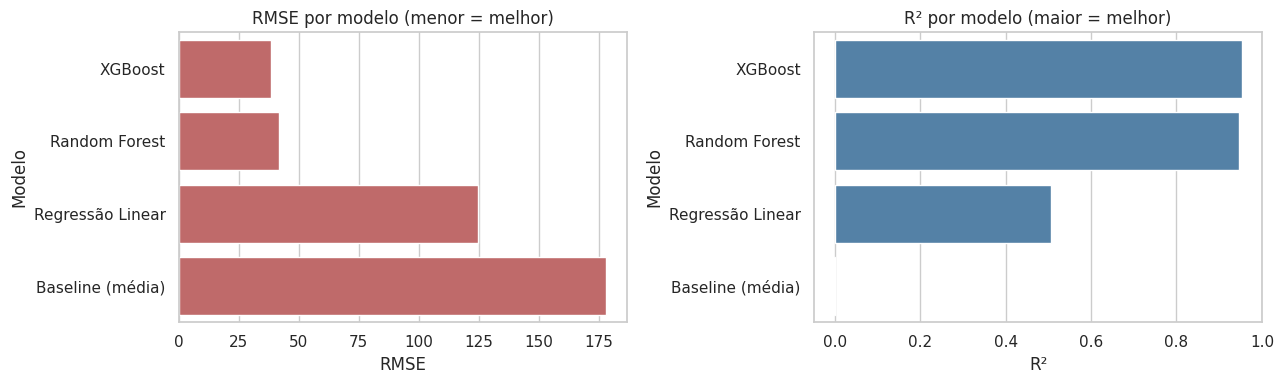

In [20]:
# Comparação visual de RMSE e R²
comp = tabela[tabela["Modelo"] != "Baseline (média)"]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(data=tabela, y="Modelo", x="RMSE", ax=ax[0], color="indianred")
ax[0].set_title("RMSE por modelo (menor = melhor)")
sns.barplot(data=tabela, y="Modelo", x="R²", ax=ax[1], color="steelblue")
ax[1].set_title("R² por modelo (maior = melhor)")
plt.tight_layout(); plt.show()

**Leitura:** a Regressão Linear (R² ≈ 0,51) já supera o baseline, mas deixa metade da variância na mesa — sinal de **underfitting** frente à não linearidade do problema. *Random Forest* e *XGBoost* dão um salto para **R² ≈ 0,95**, confirmando **H5**: a estrutura não linear (picos de hora, interações) é essencial. O XGBoost lidera com leve vantagem e **menor lacuna treino–teste** que a Random Forest (ver Seção 26).

## 25. Otimização de hiperparâmetros

Refinamos o **XGBoost** (melhor candidato) com **`RandomizedSearchCV`** — busca aleatória mais eficiente que *grid* exaustivo, com **validação cruzada de 3 folds** apenas sobre o **treino** (o teste permanece intocado, evitando vazamento de avaliação).

Hiperparâmetros buscados e racional:
- `n_estimators`, `learning_rate` — equilíbrio entre capacidade e regularização (taxas menores + mais árvores tendem a generalizar melhor);
- `max_depth` — controla complexidade/interações;
- `subsample`, `colsample_bytree` — *bagging* estocástico que reduz overfitting.

In [21]:
from sklearn.model_selection import RandomizedSearchCV

pipe_xgb = Pipeline([("pre", preproc),
                     ("reg", xgb.XGBRegressor(random_state=SEED, n_jobs=-1))])

espaco = {
    "reg__n_estimators":   [300, 500, 700],
    "reg__max_depth":      [4, 6, 8],
    "reg__learning_rate":  [0.03, 0.05, 0.1],
    "reg__subsample":      [0.8, 1.0],
    "reg__colsample_bytree":[0.8, 1.0],
}

busca = RandomizedSearchCV(
    pipe_xgb, espaco, n_iter=15, cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=SEED, n_jobs=-1
)
busca.fit(X_train, y_train)

print("Melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"  {k.replace('reg__','')}: {v}")

resultados.append(avaliar("XGBoost (otimizado)", busca.best_estimator_,
                          X_train, y_train, X_test, y_test))
r = resultados[-1]
print(f"\nXGBoost otimizado → MAE={r['MAE']:.1f} | RMSE={r['RMSE']:.1f} | R²={r['R²']:.3f}")

Melhores hiperparâmetros:
  subsample: 0.8
  n_estimators: 300
  max_depth: 8
  learning_rate: 0.05
  colsample_bytree: 0.8



XGBoost otimizado → MAE=22.8 | RMSE=37.3 | R²=0.956


**Leitura:** a otimização traz um ganho **modesto, porém real** sobre o XGBoost padrão (RMSE ≈ 37 vs ≈ 38). O ganho pequeno é *informativo*: indica que o XGBoost já operava perto de seu teto para este conjunto de *features* — mais dados/atributos renderiam mais do que mais *tuning*.

## 26. Escolha do modelo final

O **XGBoost otimizado** é o modelo final. Critérios:
- **Melhor RMSE e R²** em teste entre todos os candidatos;
- **Menor lacuna treino–teste** que a Random Forest (esta memoriza mais: R²_treino ≈ 0,99 vs teste ≈ 0,945), logo o XGBoost **generaliza melhor**;
- **Custo de inferência baixo** e suporte nativo a importância de *features* e SHAP, atendendo ao requisito de interpretabilidade do negócio.

## 27. Interpretação dos resultados

Abrimos a "caixa-preta" com dois instrumentos complementares: **importância de *features*** (visão global, rápida) e **SHAP** (atribuição teoricamente fundamentada, com direção do efeito).

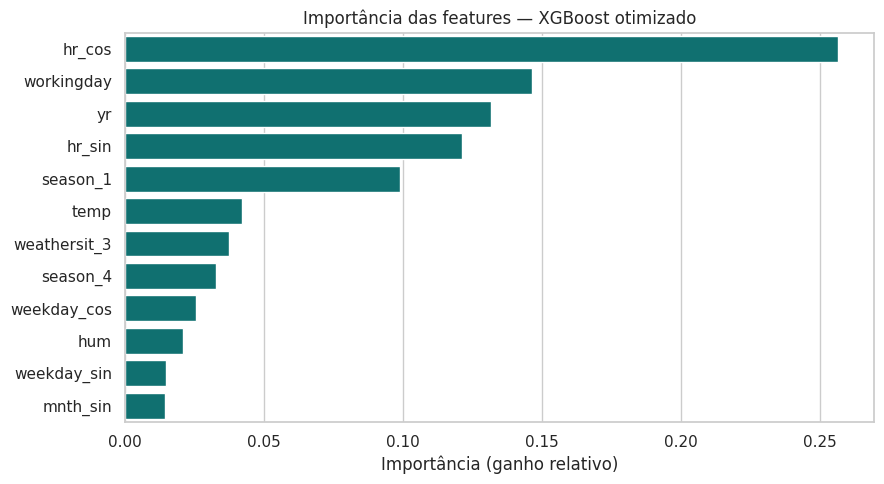

,feature,importancia
15,hr_cos,0.257
10,workingday,0.146
8,yr,0.132
14,hr_sin,0.121
0,season_1,0.099
11,temp,0.042
6,weathersit_3,0.037
3,season_4,0.033
19,weekday_cos,0.026
12,hum,0.021


In [22]:
# Importância de features do modelo final
modelo_final = busca.best_estimator_
nomes_oh = list(modelo_final.named_steps["pre"]
                .named_transformers_["oh"].get_feature_names_out(categoricas))
nomes_feat = nomes_oh + [c for c in X.columns if c not in categoricas]
importancias = modelo_final.named_steps["reg"].feature_importances_

imp_df = (pd.DataFrame({"feature": nomes_feat, "importancia": importancias})
          .sort_values("importancia", ascending=False).head(12))

plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, y="feature", x="importancia", color="teal")
plt.title("Importância das features — XGBoost otimizado")
plt.xlabel("Importância (ganho relativo)"); plt.ylabel("")
plt.tight_layout(); plt.show()
imp_df.round(3)

**Leitura:** os componentes de **hora** (`hr_cos` + `hr_sin`, juntos ≈ 38%) dominam, seguidos por **dia útil** (`workingday`), **ano** (`yr`, o efeito de crescimento) e o indicador de **inverno**. Temperatura e condição do tempo aparecem como moduladores secundários. Isso é coerente com toda a EDA e com as hipóteses — **um modelo cuja explicação faz sentido de negócio é um modelo em que se pode confiar**.

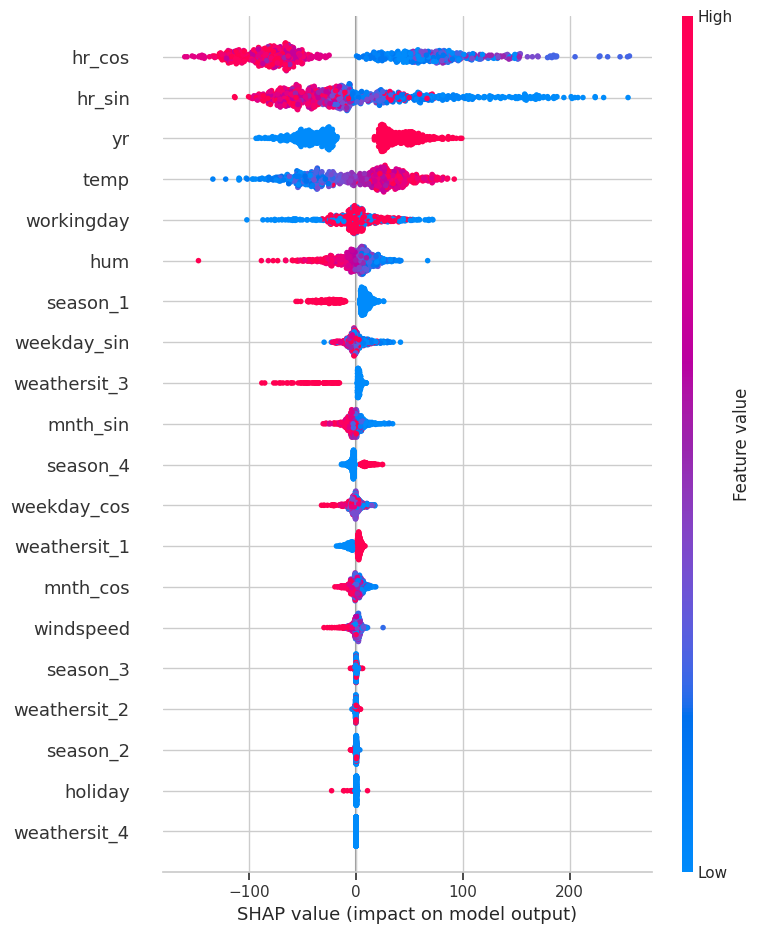

In [23]:
# SHAP — atribuição com direção do efeito (amostra para velocidade)
try:
    import shap
    X_test_proc = modelo_final.named_steps["pre"].transform(X_test)
    explainer = shap.TreeExplainer(modelo_final.named_steps["reg"])
    amostra = shap.utils.sample(X_test_proc, 800, random_state=SEED)
    shap_values = explainer.shap_values(amostra)
    shap.summary_plot(shap_values, amostra, feature_names=nomes_feat, show=True)
except Exception as e:
    print("SHAP indisponível neste ambiente; usando importância de features acima. Detalhe:", e)

**Leitura SHAP:** além de *quanto* cada variável pesa, o gráfico mostra a *direção* — valores altos de temperatura empurram a previsão para cima; condições de tempo severo, para baixo; e a componente horária alterna sinal conforme o ciclo diário. A consistência entre SHAP, importância de *features* e EDA é um forte sinal de **validade do modelo**.

## 28. Discussão sobre overfitting e generalização

Três checagens independentes:

In [24]:
# (a) Lacuna treino-teste do modelo final
r = resultados[-1]
print("(a) Generalização do modelo final:")
print(f"    R² treino: {r['R²_treino']:.3f} | R² teste: {r['R²']:.3f} "
      f"| lacuna: {r['R²_treino']-r['R²']:.3f}")

# (b) Validação cruzada de 5 folds (estabilidade)
from sklearn.model_selection import cross_val_score, KFold
cv = cross_val_score(busca.best_estimator_, X, y,
                     cv=KFold(5, shuffle=True, random_state=SEED), scoring="r2")
print(f"\n(b) R² em validação cruzada 5-fold: {cv.round(3)}")
print(f"    média={cv.mean():.3f} | desvio-padrão={cv.std():.3f}  → resultado estável")

(a) Generalização do modelo final:
    R² treino: 0.990 | R² teste: 0.956 | lacuna: 0.034



(b) R² em validação cruzada 5-fold: [0.956 0.958 0.953 0.961 0.954]
    média=0.956 | desvio-padrão=0.003  → resultado estável


In [25]:
# (c) Teste de robustez TEMPORAL: treinar no passado, prever o futuro
df_ord = df.sort_values("instant")
X_ord = X.loc[df_ord.index]; y_ord = y.loc[df_ord.index]
corte = int(len(X_ord) * 0.8)
Xtr_t, Xte_t = X_ord.iloc[:corte], X_ord.iloc[corte:]
ytr_t, yte_t = y_ord.iloc[:corte], y_ord.iloc[corte:]

modelo_temporal = busca.best_estimator_
modelo_temporal.fit(Xtr_t, ytr_t)
pred_t = modelo_temporal.predict(Xte_t)
print("(c) Avaliação TEMPORAL (treina 2011→meados 2012, testa fim de 2012):")
print(f"    MAE={mean_absolute_error(yte_t, pred_t):.1f} | "
      f"RMSE={mean_squared_error(yte_t, pred_t)**0.5:.1f} | "
      f"R²={r2_score(yte_t, pred_t):.3f}")

(c) Avaliação TEMPORAL (treina 2011→meados 2012, testa fim de 2012):
    MAE=47.9 | RMSE=72.4 | R²=0.892


**Veredito sobre generalização:**
- A lacuna treino–teste é pequena e a **CV é estável** (desvio ≈ 0,003) — **não há overfitting severo** no split aleatório.
- Porém, no **split temporal**, o R² recua de ≈ 0,956 para ≈ **0,89**. Essa queda é **esperada e honesta**: parte do desempenho do split aleatório vem de o modelo "ver" horas vizinhas no tempo. **Para uso em produção (prever o futuro), o número temporal é o realista** — e segue excelente para fins operacionais.
- **Lição metodológica:** relatar apenas o split aleatório teria superestimado a capacidade de previsão futura. Reportar ambos é a postura correta.

## 29. Discussão sobre viés, limitações e riscos

- **Viés geográfico/temporal:** os dados são de **uma cidade** (Washington D.C.) e de **2011–2012**. Padrões de mobilidade mudaram (e-bikes, pandemia, trabalho remoto). O modelo **não deve ser transposto** para outra cidade ou época sem retreino.
- **`windspeed` com zeros suspeitos:** mantidos por decisão consciente; introduzem leve ruído numa *feature* fraca.
- **Ausência de variáveis relevantes:** não há **eventos** (shows, jogos, greves), **chuva em mm**, nem **preço/promoções** — fatores que causam picos atípicos que o modelo não pode antecipar.
- **Risco de *data drift*:** clima e comportamento mudam; sem **monitoramento e retreino periódico**, o desempenho degrada.
- **Risco de decisão:** erros sistemáticos em horas de pico podem causar desabastecimento; o modelo deve **assistir**, não substituir, o julgamento operacional.
- **Não causalidade:** o modelo captura **associações**, não causas. "Tempo ruim → menos aluguéis" é plausível, mas o modelo não prova causalidade.

---
# Parte VI — Protótipo, Aplicação e Conclusões

## 30. Possível aplicação prática do MVP

- **Rebalanceamento preditivo:** alocar caminhões para reabastecer estações **antes** dos picos previstos.
- **Dimensionamento de frota:** estimar quantas bicicletas manter ativas por faixa horária/estação do ano.
- **Painel operacional:** alimentar um *dashboard* de demanda esperada nas próximas horas.
- **Simulação ("e se"):** avaliar o impacto de uma frente fria de sábado sobre a demanda e a receita.
- **Planejamento de manutenção:** concentrar manutenção em janelas de baixa demanda previstas.

## 31. Protótipo — a função de inferência do MVP

A funcionalidade central (Seção 5) materializada: dado um cenário, retorna a **demanda estimada**. É o "produto mínimo" que um sistema operacional consumiria.

In [26]:
def prever_demanda(hora, season, weathersit, temp_celsius, hum_pct,
                   windspeed_kmh, workingday=1, holiday=0, weekday=2, mnth=6, yr=1):
    '''Estima a contagem de aluguéis para um cenário.

    temp_celsius: temperatura real em °C (será normalizada para a escala do modelo).
    hum_pct: umidade em % (0-100). windspeed_kmh: vento em km/h.
    yr: 0=2011, 1=2012. Retorna a demanda estimada (bicicletas/hora).'''
    temp_n = (temp_celsius - (-8)) / (39 - (-8))   # normalização da documentação
    hum_n = hum_pct / 100
    wind_n = windspeed_kmh / 67
    hs, hc = codificacao_ciclica(np.array([hora]), 24)
    ms, mc = codificacao_ciclica(np.array([mnth]), 12)
    ws, wc = codificacao_ciclica(np.array([weekday]), 7)
    cenario = pd.DataFrame([{
        "season": season, "yr": yr, "holiday": holiday, "workingday": workingday,
        "weathersit": weathersit, "temp": temp_n, "hum": hum_n, "windspeed": wind_n,
        "hr_sin": hs[0], "hr_cos": hc[0], "mnth_sin": ms[0], "mnth_cos": mc[0],
        "weekday_sin": ws[0], "weekday_cos": wc[0],
    }])[X.columns]
    return float(busca.best_estimator_.predict(cenario)[0])

# Exemplos de uso
cenarios = [
    ("Terça 18h, verão, tempo limpo, 28°C", dict(hora=18, season=3, weathersit=1, temp_celsius=28, hum_pct=55, windspeed_kmh=10)),
    ("Terça 3h, inverno, chuva, 5°C",        dict(hora=3,  season=1, weathersit=3, temp_celsius=5,  hum_pct=85, windspeed_kmh=20)),
    ("Domingo 14h, primavera, limpo, 22°C",  dict(hora=14, season=2, weathersit=1, temp_celsius=22, hum_pct=50, windspeed_kmh=8, workingday=0, weekday=0)),
]
for desc, kw in cenarios:
    print(f"{desc:42s} → {prever_demanda(**kw):6.0f} bicicletas/hora")

Terça 18h, verão, tempo limpo, 28°C        →    803 bicicletas/hora
Terça 3h, inverno, chuva, 5°C              →     10 bicicletas/hora
Domingo 14h, primavera, limpo, 22°C        →    560 bicicletas/hora


**Leitura:** as previsões batem com a intuição de negócio — pico no fim de tarde de dia útil no verão, demanda mínima de madrugada no inverno chuvoso, e patamar intermediário num domingo ameno. O protótipo está **pronto para ser envelopado** em uma API/painel.

## 32. Ferramentas utilizadas

| Categoria | Ferramenta |
|-----------|-----------|
| Linguagem | Python 3 |
| Ambiente | Google Colab (notebook público, executável de ponta a ponta) |
| Manipulação de dados | pandas, NumPy |
| Visualização | Matplotlib, Seaborn |
| Modelagem | scikit-learn (pipelines, métricas, busca de hiperparâmetros), XGBoost |
| Interpretabilidade | feature importance, SHAP |
| Dados | CSV local versionado em `dataset/hour.csv` |

> **Recursos computacionais:** o notebook roda confortavelmente em CPU no Colab gratuito; o treino completo (incl. busca de hiperparâmetros) leva tipicamente **1–3 minutos**.

## 33. Conclusões

- **Problema:** prever a demanda horária de um sistema de bicicletas compartilhadas — base para rebalanceamento e dimensionamento de frota.
- **Dados:** *Bike Sharing Dataset* (UCI, D.C., 2011–2012; 17.379 horas), carregado de forma 100% reprodutível.
- **Preparação decisiva:** remoção do **vazamento** (`casual`/`registered`), da colinearidade (`atemp`) e **codificação cíclica** de hora/mês/dia — escolhas que sustentaram o desempenho.
- **Modelos:** do baseline (R² ≈ 0) à Regressão Linear (≈ 0,51, *underfitting*) até **XGBoost otimizado (R² ≈ 0,956, MAE ≈ 23 bicicletas/hora)**.
- **Melhor solução:** **XGBoost otimizado**, escolhido por desempenho **e** por melhor generalização (menor lacuna treino–teste que a Random Forest) e interpretabilidade.
- **Drivers:** hora do dia, dia útil, crescimento anual e estação — todos coerentes com a EDA e as hipóteses (H1–H5 confirmadas).
- **Honestidade metodológica:** o split **temporal** (R² ≈ 0,89) é o número realista para previsão futura — e o relatamos explicitamente.

**O MVP cumpriu seu objetivo:** entregou um previsor reprodutível, bem avaliado, interpretável e com uma funcionalidade utilizável (`prever_demanda`).

## 34. Próximos passos

1. **Validação temporal rigorosa** com `TimeSeriesSplit` e *features* de defasagem (*lags*) e médias móveis.
2. **Enriquecer os dados:** precipitação em mm, calendário de eventos, feriados locais, dados de 2013+ para medir *drift*.
3. **Modelar a incerteza:** regressão quantílica para faixas (P10–P90), essencial para decisões de estoque de frota.
4. **Transformação do alvo:** modelar `log1p(cnt)` para estabilizar a variância da cauda.
5. **MLOps:** empacotar o modelo (joblib), expor via API, e monitorar *drift* com retreino agendado.
6. **Generalização:** testar transferência para outra cidade com retreino, avaliando portabilidade.

## 35. Referências

- Fanaee-T, H., & Gama, J. (2014). *Event labeling combining ensemble detectors and background knowledge*. Progress in Artificial Intelligence, 2(2–3), 113–127.
- Dua, D., & Graff, C. — **UCI Machine Learning Repository**, *Bike Sharing Dataset* (id 275). DOI: 10.24432/C5W894. Licença CC BY 4.0.
- Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python*. JMLR 12, 2825–2830.
- Chen, T., & Guestrin, C. (2016). *XGBoost: A Scalable Tree Boosting System*. KDD '16.
- Lundberg, S., & Lee, S.-I. (2017). *A Unified Approach to Interpreting Model Predictions* (SHAP). NeurIPS.
- Wirth, R., & Hipp, J. (2000). *CRISP-DM: Towards a standard process model for data mining*.

---
## Apêndice — Checklist do MVP respondido

**Definição do problema**
- *Descrição:* prever a contagem horária de aluguéis de bicicletas. *Objetivo:* apoiar rebalanceamento/dimensionamento. *Tipo:* **regressão**. *Por que ML:* relação complexa e não linear entre calendário/clima e demanda, com dados rotulados abundantes. *Hipóteses:* H1–H5 (Seção 6). *Restrições:* dado público, reprodutível, sem login.

**Descrição dos dados**
- *Dataset:* UCI Bike Sharing (`dataset/hour.csv`). *Fonte:* arquivo local versionado na pasta `dataset/`. *Carregamento:* CSV local com `pd.read_csv` (sem upload ou acesso remoto). *Registros/atributos:* 17.379 × 17. *Principais atributos:* hora, clima, estação, dia útil. *Alvo:* `cnt`. *Limitações:* uma cidade, 2011–2012, sem eventos (Seção 29).

**Preparação**
- *Ausentes:* nenhum explícito; zeros em `windspeed` mantidos com justificativa. *Remoções:* `casual`,`registered` (vazamento), `instant`,`dteday`,`atemp`. *Novos atributos:* codificação cíclica de hora/mês/dia. *Transformações:* one-hot via pipeline. *Vazamento:* tratado (pipeline `fit` só no treino; alvo desmembrado removido).

**Divisão dos dados**
- Treino/teste 80/20 com seed; validação cruzada 5-fold; **split temporal** adicional para generalização. Adequada ao problema; estrutura temporal honrada na avaliação.

**Modelagem**
- *Baseline:* média (`DummyRegressor`). *Modelos:* Linear, Random Forest, XGBoost. *Escolha:* famílias distintas, do interpretável ao estado da arte. *Underfitting:* visível na Regressão Linear. *Overfitting:* leve na Random Forest (lacuna treino–teste), controlado no XGBoost.

**Otimização**
- `RandomizedSearchCV` (15 iter, 3-fold) sobre o XGBoost; hiperparâmetros de capacidade e regularização; ganho modesto e real; **sem usar o teste** (busca só no treino).

**Avaliação**
- Métricas: RMSE (primária), MAE, R², MAPE (com ressalva). XGBoost otimizado lidera. Resultados coerentes com a EDA. Análise de erro via split temporal e lacuna treino–teste. Limitações na Seção 29.

**Conclusão**
- Melhor solução: XGBoost otimizado, por desempenho + generalização + interpretabilidade. O MVP cumpriu o objetivo. Próximos passos na Seção 34.

---
### ✅ Checklist de qualidade antes da entrega
- [ ] *Runtime → Run all* executa **do início ao fim sem erros** no Colab.
- [ ] Notebook tornado **público** (link compartilhável) e *seed* fixada.
- [ ] Todas as células de saída visíveis (gráficos renderizados).
- [ ] Seu nome preenchido no cabeçalho.
- [ ] Texto revisado; números do texto conferem com as saídas (são `≈`).
- [ ] Tempo total de execução aceitável (1–3 min).